# Decision Tree Classifier

In [37]:
#import libraries

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

#
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score

In [20]:
#load the dataset for multiclass classification
data = sns.load_dataset("iris")
data[:5]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [21]:
#shape
data.shape

(150, 5)

In [22]:
#data type
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [23]:
#check null values
data.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [24]:
#check duplicates

data.duplicated().sum()

#drop
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

In [25]:
#convert label to numeric

data["species"].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [26]:
#convert label to numeric
data["species"] = data["species"].map({'setosa':0, 'versicolor':1, 'virginica':2})

data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [43]:
data["species"].value_counts()

species
0    50
1    50
2    49
Name: count, dtype: int64

In [28]:
#seperate data into label and features set

X = data.drop("species", axis=1)
y = data['species']

In [31]:
#seperate train and test set

x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=.2, random_state=42, stratify=y)

In [33]:
#train the model

model  =DecisionTreeClassifier()

model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [34]:
#check score on training set
model.score(x_train, y_train)

1.0

In [36]:
#predict
y_pred = model.predict(x_test)

pd.DataFrame({"actual": y_test, "Predicted": y_pred})[:5]

,actual,Predicted
69,1,1
66,1,1
141,2,2
7,0,0
147,2,2


In [38]:
#accuracy
accuracy_score(y_test, y_pred)

0.9333333333333333

In [39]:
#confusion matrix

conm = confusion_matrix(y_test, y_pred)
conm

array([[10,  0,  0],
       [ 0,  9,  1],
       [ 0,  1,  9]])

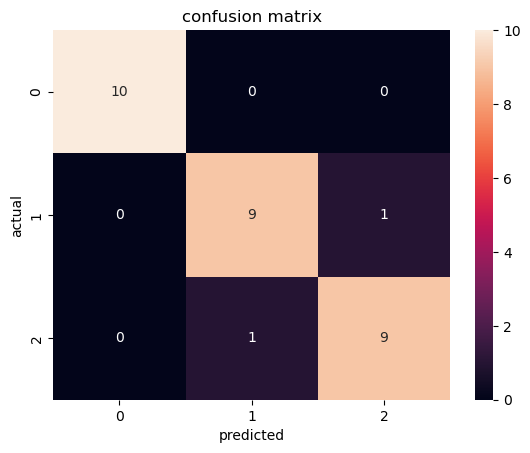

In [41]:
sns.heatmap(conm, annot=True)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion matrix");

In [42]:
#get claiification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



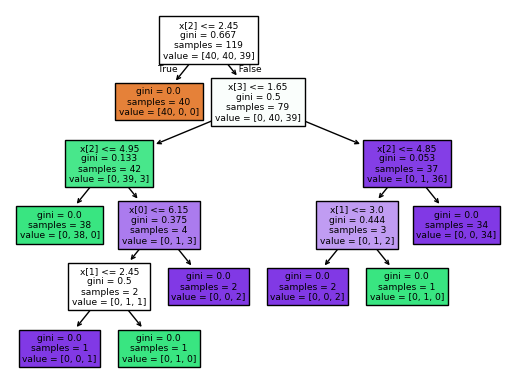

In [45]:
#plot the model
tree.plot_tree(model, filled=True);

# CART MOdel 

when critetion is entropy the decisition tree model is called CART(Categorical and regression tree)

In [46]:
#CART the model

model1  =DecisionTreeClassifier(criterion='entropy')

model1.fit(x_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [50]:
#predict
y_pred1 = model.predict(x_test)

pd.DataFrame({"actual": y_test, "Predicted": y_pred})[:5]

,actual,Predicted
69,1,1
66,1,1
141,2,2
7,0,0
147,2,2


In [51]:
accuracy_score(y_test, y_pred1)

0.9333333333333333

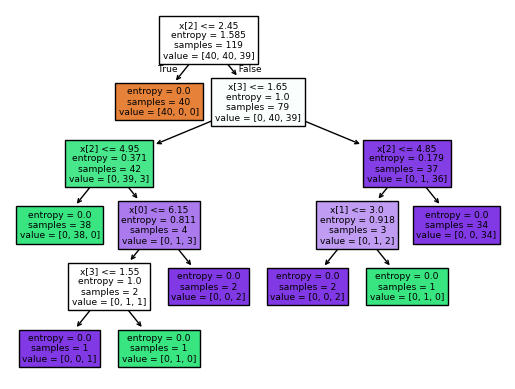

In [52]:
#plot the model
plot_tree(model1, filled=True);

## Feature importance  

This is done after model

In [54]:
#check feature importance

feature = model.feature_importances_
feature

array([0.00630297, 0.02941384, 0.56119217, 0.40309102])

In [58]:
names = model.feature_names_in_
names

array(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
      dtype=object)

In [61]:
feature_df = pd.DataFrame({"feature_name": names, "feature_val": feature})
feature_df.sort_values(by="feature_val", ascending=False)

,feature_name,feature_val
2,petal_length,0.561192
3,petal_width,0.403091
1,sepal_width,0.029414
0,sepal_length,0.006303


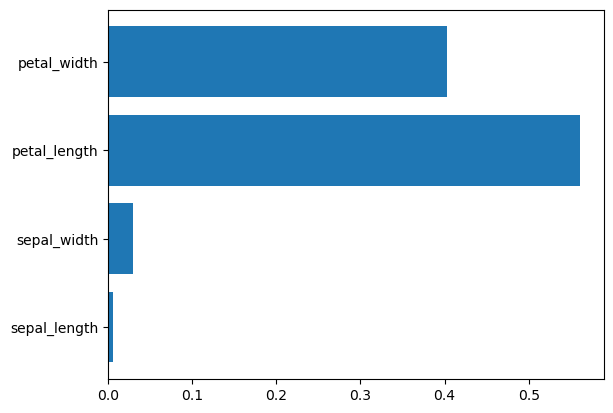

In [65]:
#visualize this barchart

plt.barh(feature_df["feature_name"], feature_df["feature_val"]);